In [3]:
# Code from Ashley Tarrant

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

df = pd.read_csv('..\\data\\prelim-3-data.csv')

print(df.head())

def V_r(R, Z, V_0):
    return ((R - Z)/(R + Z)) * V_0

def dV_r(R, Z, V_0):
    term1 = V_0 / (R + Z)
    term2 = V_0 * (R - Z) / ((R + Z)**2)
    return term1-term2

def friend1(R, Z, V_0):
    return ((R**2. - Z**2.)/(R**2. + Z**2.)) * V_0

def dV_dR_f1(R, Z, V_0):
    return (4 * V_0 * Z**2. * R) / (R**2. + Z**2.)**2.

def friend2(R, Z, V_0):
    return ((np.sqrt(R) - np.sqrt(Z))/(np.sqrt(R) + np.sqrt(Z))) * V_0

def dV_dR_f2(R, Z, V_0):
    return (V_0 * np.sqrt(Z)) / ((np.sqrt(R) + np.sqrt(Z))**2. * np.sqrt(R))

xdata = df['R'].to_numpy()
ydata = df['V'].to_numpy()
xerr = df['R_err'].to_numpy()
yerr = df['V_err'].to_numpy()

      R  R_err      V  V_err
0  10.0    0.1  2.910  0.060
1  20.0    0.2  1.380  0.040
2  30.1    0.3  1.180  0.030
3  40.3    0.4  0.473  0.002
4  49.9    0.5  0.000  0.000


Equation 1

In [4]:
popt_uw_me, pcov_uw_me = curve_fit(V_r, xdata, ydata, p0=[50,-4])
sigmas_me = np.sqrt( yerr ** 2 + (xerr**2 * dV_r(xdata, popt_uw_me[0], popt_uw_me[1])**2 ) )
popt_me, pcov_me = curve_fit(V_r, xdata, ydata, sigma=sigmas_me)

Friend 1

In [5]:
popt_uw_f1, pcov_uw_f1 = curve_fit(friend1, xdata, ydata)
sigmas_f1 = np.sqrt( yerr ** 2 + (xerr**2 * dV_dR_f1(xdata, popt_uw_f1[0], popt_uw_f1[1])**2 ) )
popt_f1, pcov_f1 = curve_fit(friend1, xdata, ydata, sigma=sigmas_f1)

Friend 2

In [6]:
popt_uw_f2, pcov_uw_f2 = curve_fit(friend2, xdata, ydata)
sigmas_f2 = np.sqrt( yerr ** 2 + (xerr**2 * dV_dR_f2(xdata, popt_uw_f2[0], popt_uw_f2[1])**2 ) )
popt_f2, pcov_f2 = curve_fit(friend2, xdata, ydata, sigma=sigmas_f2)

C:\Users\Connor Fricke\AppData\Local\Temp\ipykernel_16192\1206747808.py:25: RuntimeWarning: invalid value encountered in sqrt
  return ((np.sqrt(R) - np.sqrt(Z))/(np.sqrt(R) + np.sqrt(Z))) * V_0


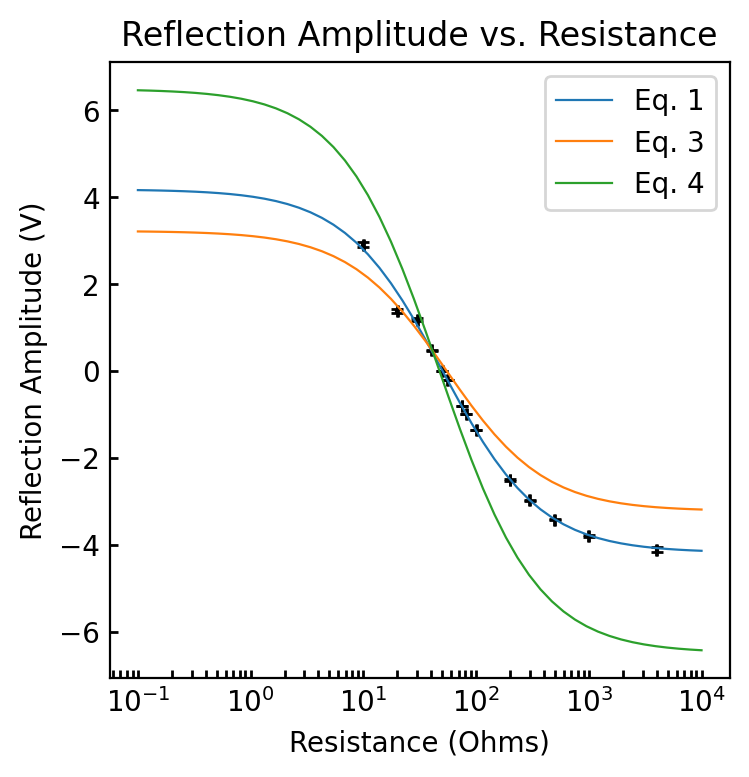

In [8]:
xdata_fit = np.logspace(-1, 4.0, 50)
ydata_fit_me = V_r(xdata_fit, popt_me[0], popt_me[1])
ydata_fit_f1 = V_r(xdata_fit, popt_f1[0], popt_f1[1])
ydata_fit_f2 = V_r(xdata_fit, popt_f2[0], popt_f2[1])

fig, ax = plt.subplots(dpi=200,figsize=(4,4))
plt.errorbar(xdata, ydata, xerr=xerr, yerr=yerr, ls='none', c='k', capsize=2)

plt.plot(xdata_fit, ydata_fit_me, label='Eq. 1', lw=0.8)
plt.plot(xdata_fit, ydata_fit_f1, label='Eq. 3', lw=0.8)
plt.plot(xdata_fit, ydata_fit_f2, label='Eq. 4', lw=0.8)

plt.title('Reflection Amplitude vs. Resistance')
plt.xlabel('Resistance (Ohms)')
plt.ylabel('Reflection Amplitude (V)')
plt.xscale('log')

plt.tick_params(which='both',direction='in', length=3, width=1, color='k')


plt.legend()
# plt.savefig('RelfV_v_Res.pdf',bbox_inches='tight')

In [9]:
N = len(xdata)
Red_Chi2_me = 1.0/(N-2) * np.sum((ydata - V_r(xdata, popt_me[0],popt_me[1]))**2 / sigmas_me**2)
print('Reduced Chi Squared= ', Red_Chi2_me)

Red_Chi2_f1 = 1.0/(N-2) * np.sum((ydata - friend1(xdata, popt_f1[0],popt_f1[1]))**2 / sigmas_f1**2)
print('Reduced Chi Squared= ', Red_Chi2_f1)

Red_Chi2_f2 = 1.0/(N-2) * np.sum((ydata - friend2(xdata, popt_f2[0],popt_f2[1]))**2 / sigmas_f2**2)
print('Reduced Chi Squared= ', Red_Chi2_f2)

Reduced Chi Squared=  9.777179736132778
Reduced Chi Squared=  278.9927996192709
Reduced Chi Squared=  144.60671109291775


In [10]:
print(popt_me[0], popt_me[1])
print(popt_f1[0], popt_f1[1])
print(popt_f2[0], popt_f2[1])

50.44066328396866 -4.180845489800804
54.92579878435606 -3.224173581491133
47.38588649672147 -6.4899953356908355


In [11]:
print(np.sqrt(np.diag(pcov_me)))
print(np.sqrt(np.diag(pcov_f1)))
print(np.sqrt(np.diag(pcov_f2)))

[0.61387012 0.03800863]
[3.34283253 0.13277003]
[2.29192348 0.25599351]
